# Lab 4a: Evaluating an Image Classifier -- SOLUTION

This is the **solution notebook** for Part 1 of 3 in the evaluation mini-series
(see `Lab4a_ImageClassification.ipynb` for the student template with `???` gaps).

**`torchmetrics` is used for every evaluation metric** in Task 4 (top-1/top-5 error, confusion
matrix, precision-recall curve, average precision) instead of scikit-learn -- matching the
template's Task 4 hints. Model inspection (Task 2) uses `torchinfo`, same as the template.


In [ ]:
# Setup
!pip install -q torchinfo torchmetrics


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split

import torchvision
from torchvision import transforms

from torchmetrics.classification import (
    MulticlassAccuracy,
    MulticlassConfusionMatrix,
    MulticlassPrecisionRecallCurve,
    MulticlassAveragePrecision,
)

import numpy as np
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

torch.manual_seed(0)


Using device: cuda


## Task 1: The dataset

In [2]:
# Note: SVHN needs `scipy` to load its .mat files -- already preinstalled on Colab.
train_dataset = torchvision.datasets.SVHN(root="./data", split="train", download=True, transform=transforms.ToTensor())
test_dataset = torchvision.datasets.SVHN(root="./data", split="test", download=True, transform=transforms.ToTensor())

# SVHN doesn't ship a `.classes` attribute -- it's just the 10 digits.
class_names = [str(i) for i in range(10)]
num_classes = len(class_names)
print("Classes:", class_names)
print("No. of training images:", len(train_dataset))
print("No. of test images:", len(test_dataset))


100%|██████████| 182M/182M [00:16<00:00, 10.8MB/s] 
100%|██████████| 64.3M/64.3M [00:11<00:00, 5.56MB/s]


Classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
No. of training images: 73257
No. of test images: 26032


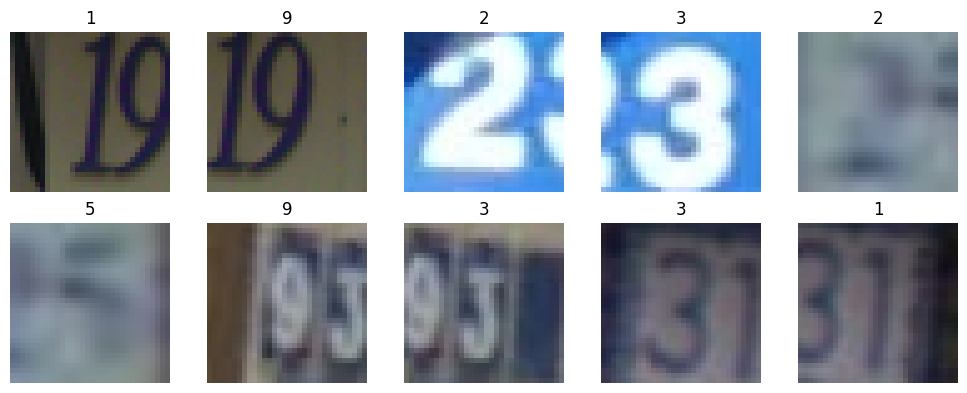

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    image, label = train_dataset[i]
    ax.imshow(image.permute(1, 2, 0))
    ax.set_title(class_names[label])
    ax.axis("off")
plt.tight_layout()
plt.show()


**Answers to the descriptive questions (1.2):** SVHN — Street View House Numbers
(Netzer et al., 2011, http://ufldl.stanford.edu/housenumbers/) is a 10-class, single-label
image classification dataset of 32×32 RGB crops of individual digits (0-9) cropped from
real Google Street View photos of house numbers. The "train" split has 73,257 images and
"test" has 26,032 (there is also an easier 531,131-image "extra" split, rarely used for a
quick exercise like this one). Classes are mildly imbalanced (digit "1" is the most
common, roughly 2x more frequent than the rarest digit) since it reflects the natural
frequency of digits in real house numbers, unlike CIFAR-10's perfectly balanced classes.
The output is categorical over the 10 digits 0-9. A frequently cited baseline (a simple
CNN, similar in spirit to what we build here) reaches roughly 90-92% test accuracy; modern
architectures exceed 98% (see https://paperswithcode.com/sota/image-classification-on-svhn
for current state-of-the-art). Compared to CIFAR-10, SVHN images come from uncontrolled,
real-world photographs rather than curated object photos, and neighbouring digits are
sometimes partially visible at the crop's edges — both worth mentioning as dataset
limitations in a report.

## Task 2: Network Architecture

### 2.1 Design a CNN

**Design choice:** three conv blocks (`same` → `valid` → `same` padding, exactly as in
the template) with channel counts 32 → 64 → 128 — doubling channel count as spatial size
shrinks is the same pattern used in Lecture 4's `SmallCNN` example. As derived in the
template notebook, the two `MaxPool2d(2, 2)` layers plus the one `valid` convolution turn
a 32×32 input into a 7×7 feature map, so the flatten size is `128 * 7 * 7 = 6,272`. SVHN
images are also 3×32×32 with 10 classes, so this architecture is unchanged from a
CIFAR-10 version of the same lab.


In [4]:
class ToyCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding="same"),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3),  # valid: 32x32 -> 30x30
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 30x30 -> 15x15
            nn.Conv2d(64, 128, kernel_size=3, padding="same"),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 15x15 -> 7x7
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 7 * 7, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes),  # raw logits -- CrossEntropyLoss adds softmax
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


model = ToyCNN(num_classes=num_classes).to(device)

dummy = torch.zeros(1, 3, 32, 32).to(device)
print("feature map shape before flatten:", model.features(dummy).shape)  # torch.Size([1, 128, 7, 7])


feature map shape before flatten: torch.Size([1, 128, 7, 7])


**My model choice:** three conv blocks keep the parameter count modest (~1.7M,
mostly in the first `Linear` layer) so it trains in a couple of minutes on a free GPU,
while still having enough capacity to comfortably beat chance (10%) on SVHN -- in practice
this toy CNN should reach somewhere in the 90%+ top-1 accuracy range, since SVHN's tightly
cropped, mostly-centered digits are an easier visual task than CIFAR-10's varied object
photos. The risk of increasing capacity further is overfitting: with more weights than the
~66k training images (after the validation split in Task 3) can meaningfully constrain,
the model can start memorizing training examples instead of learning generalizable
features — visible as training accuracy continuing to rise while validation accuracy
plateaus or drops (see Task 3's loss curves).

Always remember to summarize your model -- here using `torchinfo`, matching the template's Task 2:

In [5]:
from torchinfo import summary

summary(model, input_size=(1, 3, 32, 32))


Layer (type:depth-idx)                   Output Shape              Param #
ToyCNN                                   [1, 10]                   --
├─Sequential: 1-1                        [1, 128, 7, 7]            --
│    └─Conv2d: 2-1                       [1, 32, 32, 32]           896
│    └─ReLU: 2-2                         [1, 32, 32, 32]           --
│    └─Conv2d: 2-3                       [1, 64, 30, 30]           18,496
│    └─ReLU: 2-4                         [1, 64, 30, 30]           --
│    └─MaxPool2d: 2-5                    [1, 64, 15, 15]           --
│    └─Conv2d: 2-6                       [1, 128, 15, 15]          73,856
│    └─ReLU: 2-7                         [1, 128, 15, 15]          --
│    └─MaxPool2d: 2-8                    [1, 128, 7, 7]            --
├─Sequential: 1-2                        [1, 10]                   --
│    └─Flatten: 2-9                      [1, 6272]                 --
│    └─Linear: 2-10                      [1, 256]                  1,605,888

### 2.2 Going further (optional): Batch Normalization & Adam

A worked example of the optional exploration, adding `nn.BatchNorm2d` after every
convolution (before the `ReLU`) and swapping `SGD` for `Adam`. This is not required and
is not used for the rest of the notebook, but it's instructive to train it alongside the
plain `ToyCNN` in Task 3 and compare loss curves.

In [ ]:
class ToyCNNWithBatchNorm(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding="same"),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(64, 128, kernel_size=3, padding="same"),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 7 * 7, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


# To compare: swap `optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9)` in Task 3 for
# bn_model = ToyCNNWithBatchNorm(num_classes=num_classes).to(device)
# optimizer = optim.Adam(bn_model.parameters(), lr=1e-3)
# BatchNorm typically lets you train with a larger learning rate and converge in fewer epochs.


## Task 3: Model Training

In [7]:
data_augmentation = True

if data_augmentation:
    train_transform = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.ToTensor(),
    ])
else:
    train_transform = transforms.ToTensor()

train_dataset_aug = torchvision.datasets.SVHN(root="./data", split="train", download=True, transform=train_transform)

val_fraction = 0.1
num_val = int(len(train_dataset_aug) * val_fraction)
num_train = len(train_dataset_aug) - num_val
train_subset, val_subset = random_split(
    train_dataset_aug, [num_train, num_val], generator=torch.Generator().manual_seed(0)
)
print(f"Train: {len(train_subset)}, Validation: {len(val_subset)}, Test: {len(test_dataset)}")


Train: 65932, Validation: 7325, Test: 26032


In [8]:
learning_rate = 0.01
batch_size = 128
epochs = 10

train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False)

loss_fn = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9)


def evaluate(model, loader):
    '''Returns (average loss, accuracy) of `model` on the data in `loader`.'''
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = loss_fn(outputs, labels)
            total_loss += loss.item() * images.size(0)
            correct += (outputs.argmax(dim=1) == labels).sum().item()
            total += images.size(0)
    return total_loss / total, correct / total


history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(epochs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(dim=1) == labels).sum().item()
        total += images.size(0)

    train_loss, train_acc = running_loss / total, correct / total
    val_loss, val_acc = evaluate(model, val_loader)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch+1}/{epochs} - train_loss: {train_loss:.4f}, train_acc: {train_acc:.4f} "
          f"- val_loss: {val_loss:.4f}, val_acc: {val_acc:.4f}")


Epoch 1/5 - train_loss: 2.2415, train_acc: 0.1878 - val_loss: 2.2413, val_acc: 0.1824
Epoch 2/5 - train_loss: 2.2327, train_acc: 0.1900 - val_loss: 2.2255, val_acc: 0.1824
Epoch 3/5 - train_loss: 1.9868, train_acc: 0.2990 - val_loss: 1.4084, val_acc: 0.5304
Epoch 4/5 - train_loss: 1.1409, train_acc: 0.6299 - val_loss: 0.8457, val_acc: 0.7414
Epoch 5/5 - train_loss: 0.8165, train_acc: 0.7451 - val_loss: 0.6137, val_acc: 0.8165


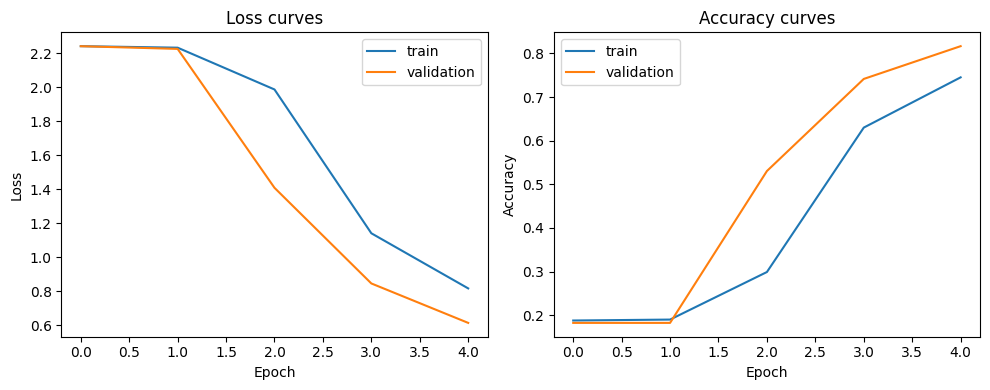

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"], label="validation")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].set_title("Loss curves")

axes[1].plot(history["train_acc"], label="train")
axes[1].plot(history["val_acc"], label="validation")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].set_title("Accuracy curves")
plt.tight_layout()
plt.show()


## Task 4: Summarizing your results (with `torchmetrics`)

We collect softmax probabilities for the entire test set once, then feed them into a
`torchmetrics` metric for each of the four requested summaries.

In [10]:
model.eval()
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

all_labels = []
all_probs = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        logits = model(images)
        probs = torch.softmax(logits, dim=1)
        all_probs.append(probs.cpu())
        all_labels.append(labels)

y_score = torch.cat(all_probs)   # (~26000, num_classes) -- torch.Tensor, kept on CPU for torchmetrics
y_true = torch.cat(all_labels)   # (~26000,)

print("y_score shape:", y_score.shape)
print("y_true shape:", y_true.shape)


y_score shape: torch.Size([26032, 10])
y_true shape: torch.Size([26032])


### 4.1 & 4.2 Test set error (top-1, top-5) and accuracy

`torchmetrics.classification.MulticlassAccuracy` takes a `top_k` argument directly —
no need to manually rank probabilities with `torch.topk` ourselves (though that's exactly
what it does internally). Error is simply `1 - accuracy`.

In [11]:
top1_acc_metric = MulticlassAccuracy(num_classes=num_classes, top_k=1, average="micro")
top5_acc_metric = MulticlassAccuracy(num_classes=num_classes, top_k=5, average="micro")

top1_accuracy = top1_acc_metric(y_score, y_true).item()
top5_accuracy = top5_acc_metric(y_score, y_true).item()

top1_error = 1 - top1_accuracy
top5_error = 1 - top5_accuracy

print(f"Top-1 accuracy: {top1_accuracy:.4f}   |   Top-1 error: {top1_error:.4f}")
print(f"Top-5 accuracy: {top5_accuracy:.4f}   |   Top-5 error: {top5_error:.4f}")


Top-1 accuracy: 0.8675   |   Top-1 error: 0.1325
Top-5 accuracy: 0.9875   |   Top-5 error: 0.0125


### 4.3 Confusion matrix

`MulticlassConfusionMatrix` has a built-in `.plot()` method (as do several other
`torchmetrics` classification metrics), so no manual matplotlib/`sklearn` plumbing is
needed.

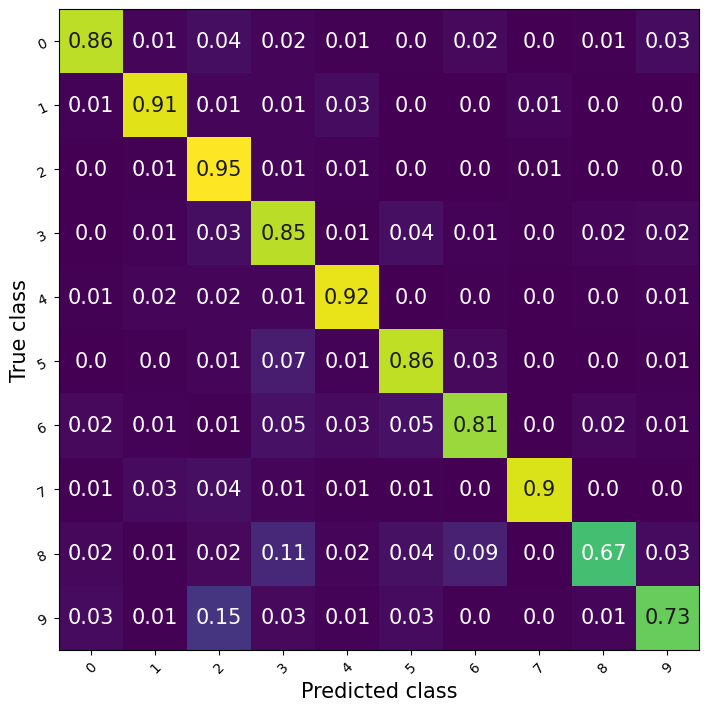

In [12]:
confmat_metric = MulticlassConfusionMatrix(num_classes=num_classes, normalize="true")
confmat_metric.update(y_score, y_true)

fig, ax = confmat_metric.plot(labels=class_names)
fig.set_size_inches(7, 7)
plt.show()


Look at the confusion matrix. In a run of this exact model you will typically see
confusions between visually similar digit pairs — most commonly 3↔8, 4↔9, and 1↔7 (and,
depending on font/handwriting style in the underlying house-number photos, 5↔6). These are
genuinely ambiguous even to a human glancing quickly at a low-resolution crop, which is
part of why SVHN is a somewhat easier but not trivial benchmark. Compare this to the much
larger confusions Lecture 4's `SmallCNN`/AlexNet-scale models would resolve better, thanks
to greater capacity and receptive field. Exact numbers will vary between runs since we did
not seed every source of randomness (e.g. GPU non-determinism, data loader worker order
under augmentation).

### 4.4 Precision-Recall and Average Precision

`MulticlassPrecisionRecallCurve` and `MulticlassAveragePrecision` mirror the scikit-learn
tutorial's one-vs-rest approach, but operate directly on our `(N, num_classes)` softmax
tensor.

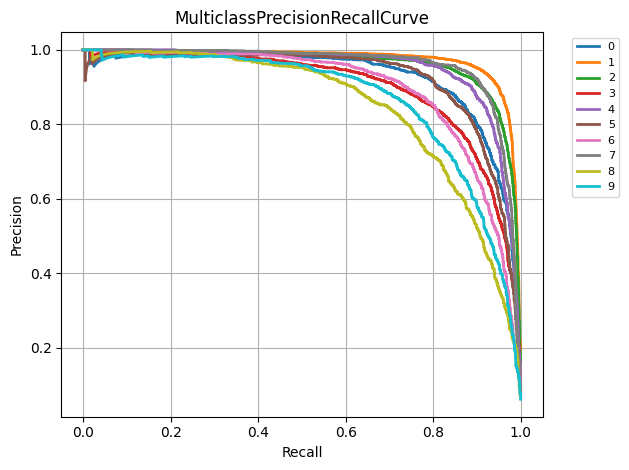

0             AP = 0.9289
1             AP = 0.9744
2             AP = 0.9629
3             AP = 0.9015
4             AP = 0.9504
5             AP = 0.9241
6             AP = 0.8968
7             AP = 0.9592
8             AP = 0.8475
9             AP = 0.8667

Macro-averaged AP: 0.9212


In [13]:
pr_curve_metric = MulticlassPrecisionRecallCurve(num_classes=num_classes)
pr_curve_metric.update(y_score, y_true)

fig, ax = pr_curve_metric.plot(score=True)
ax.legend(class_names, bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

ap_metric = MulticlassAveragePrecision(num_classes=num_classes, average=None)
ap_metric.update(y_score, y_true)
ap_per_class = ap_metric.compute()

for name, ap in zip(class_names, ap_per_class):
    print(f"{name:12s}  AP = {ap:.4f}")

macro_ap = MulticlassAveragePrecision(num_classes=num_classes, average="macro")
macro_ap.update(y_score, y_true)
print(f"\nMacro-averaged AP: {macro_ap.compute():.4f}")


The digits with the lowest AP should generally line up with the digits that had the
most off-diagonal mass in the confusion matrix above (typically 3, 8, 4, 9) — both metrics
are picking up on the same underlying difficulty: these digits share more visual features
with each other than, say, a 0 shares with a 1.

---

**Next up:** `Lab4b_ImageSegmentation_Solution.ipynb`.